<a href="https://colab.research.google.com/github/Ragul-S-2025/ML/blob/main/Normaldistributi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing Nesscary Libraries
import pandas as pd
import numpy as np
data=pd.read_csv("/content/Project 1 - Weather Dataset.csv")
data.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [2]:
# Count the weather labels
data[["Weather"]].value_counts()

,count
Weather,
Mainly Clear,2106
Mostly Cloudy,2069
Cloudy,1728
Clear,1326
Snow,390
Rain,306
Rain Showers,188
Fog,150
"Rain,Fog",116


In [3]:
# Check the null values
data.isnull().sum()

,0
Date/Time,0
Temp_C,0
Dew Point Temp_C,0
Rel Hum_%,0
Wind Speed_km/h,0
Visibility_km,0
Press_kPa,0
Weather,0


In [4]:
# View the total columns
data.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [5]:
# Set indepent varibale
ind=data[['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%','Wind Speed_km/h', 'Visibility_km', 'Press_kPa',]]

In [6]:
# The output or dependent variable is mutiple labels ,so i change into 5 categoreies

def categorize_weather(y):
    y= y.lower()
    if "clear" in y:
        return "Clear"
    elif "cloud" in y or "haze" in y:
        return "Cloudy"
    elif "rain" in y or "drizzle" in y or "thunderstorm" in y:
        return "Rainy"
    elif "snow" in y or "pellet" in y or "freezing" in y:
        return "Snowy"
    elif "fog" in y or "mist" in y:
        return "Foggy"
    else:
        return "Other"

data["Weather_Category"] = data["Weather"].apply(categorize_weather)


In [7]:
# Set dependent  Variable
y=data[["Weather_Category"]]

In [8]:
# count the new weather category type
data[["Weather_Category"]].value_counts()

,count
Weather_Category,
Cloudy,3826
Clear,3432
Rainy,849
Snowy,527
Foggy,150


In [9]:
# Using sklearn into split traina nd test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(ind, y, test_size=0.20, random_state=42)

In [10]:
X_train

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
6315,8.0,4.8,80,4,25.0,101.91
2484,13.5,-3.0,32,24,48.3,101.52
167,0.4,-1.5,87,22,9.7,100.62
5700,29.1,17.3,49,7,48.3,101.92
367,-17.9,-21.5,73,4,48.3,102.96
...,...,...,...,...,...,...
5734,23.9,16.9,65,15,25.0,101.52
5191,21.8,15.3,67,17,48.3,101.75
5390,26.4,17.0,56,13,48.3,100.62
860,-2.8,-8.0,67,24,25.0,101.25


In [11]:
# Model Trainng used To tree based algorthm am using decsion treeclassifier
from sklearn import tree
clf = tree.DecisionTreeClassifier()
clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [12]:
# predcted varaible into test data
y_pred=clf.predict(X_test)
y_pred

array(['Clear', 'Cloudy', 'Cloudy', ..., 'Clear', 'Cloudy', 'Cloudy'],
      dtype=object)

In [13]:
# To view the classifiaction report and confus matrix
from sklearn.metrics import classification_report, confusion_matrix

cls=classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=["Clear","Cloudy","Rainy","Snowy","Foggy"])
print(pd.DataFrame(cm, index=["Actual_Clear","Actual_Cloudy","Actual_Rainy","Actual_Snowy","Actual_Foggy"],
                      columns=["Pred_Clear","Pred_Cloudy","Pred_Rainy","Pred_Snowy","Pred_Foggy"]))

               Pred_Clear  Pred_Cloudy  Pred_Rainy  Pred_Snowy  Pred_Foggy
Actual_Clear          439          212          12           2           0
Actual_Cloudy         222          505          37          14           0
Actual_Rainy           14           47          83           9          10
Actual_Snowy            9           24           5          75           3
Actual_Foggy            0            1           9           3          22


**Report**



i am creating confusionn matrix for my dataset, it predict and show the actual and predicr data.
DIAGONAL -- Is show the Correct Prediction
OFF-DIAGONAL-- mistakes or missclassified data



In [14]:
print(cls)

              precision    recall  f1-score   support

       Clear       0.64      0.66      0.65       665
      Cloudy       0.64      0.65      0.64       778
       Foggy       0.63      0.63      0.63        35
       Rainy       0.57      0.51      0.54       163
       Snowy       0.73      0.65      0.68       116

    accuracy                           0.64      1757
   macro avg       0.64      0.62      0.63      1757
weighted avg       0.64      0.64      0.64      1757



In [15]:
cm

array([[439, 212,  12,   2,   0],
       [222, 505,  37,  14,   0],
       [ 14,  47,  83,   9,  10],
       [  9,  24,   5,  75,   3],
       [  0,   1,   9,   3,  22]])

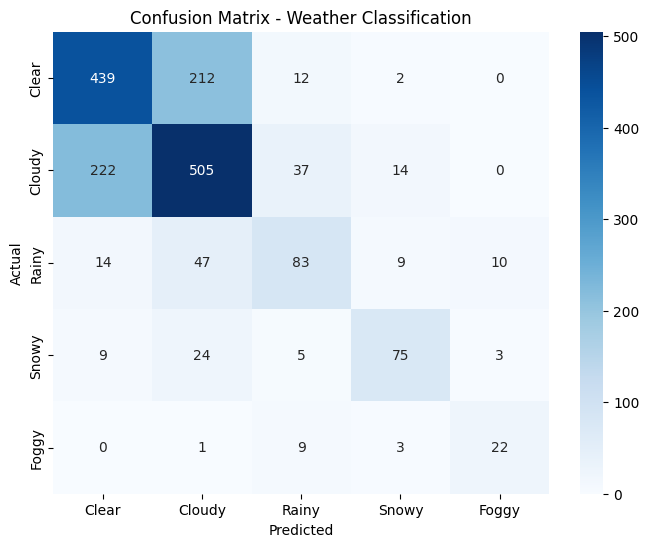

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clear","Cloudy","Rainy","Snowy","Foggy"],
            yticklabels=["Clear","Cloudy","Rainy","Snowy","Foggy"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Weather Classification")
plt.show()

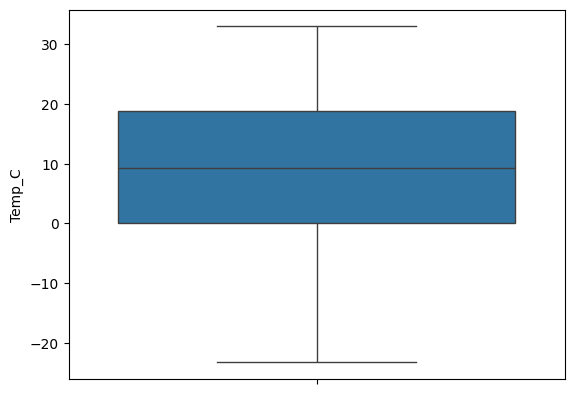

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=data['Temp_C'])
plt.show()


In [18]:
Q1 = data['Temp_C'].quantile(0.25)
Q3 = data['Temp_C'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['Temp_C'] < (Q1 - 1.5 * IQR)) |
              (data['Temp_C'] > (Q3 + 1.5 * IQR))]


In [19]:
outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category


In [20]:
import numpy as np
from scipy import stats

z_scores = np.abs(stats.zscore(data['Temp_C']))
temp_outliers = data[z_scores > 3]

In [21]:
outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category


In [22]:
z_scores = np.abs(stats.zscore(data['Dew Point Temp_C']))
dew_outliers = data[z_scores > 3]
dew_outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category


In [23]:
z_scores = np.abs(stats.zscore(data['Rel Hum_%']))
rel_outliers = data[z_scores > 3]
rel_outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category


In [24]:
z_scores = np.abs(stats.zscore(data['Wind Speed_km/h']))
wind_outliers = data[z_scores > 3]
wind_outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category
33,1/2/2012 9:00,1.8,-3.7,67,44,24.1,99.14,Mostly Cloudy,Cloudy
34,1/2/2012 10:00,1.5,-4.1,66,43,24.1,99.18,Mostly Cloudy,Cloudy
36,1/2/2012 12:00,1.7,-6.2,56,48,24.1,99.21,Mainly Clear,Clear
409,1/18/2012 1:00,3.7,-2.1,66,83,25.0,98.36,Mostly Cloudy,Cloudy
410,1/18/2012 2:00,0.5,-4.0,72,70,25.0,98.62,Mostly Cloudy,Cloudy
...,...,...,...,...,...,...,...,...,...
8538,12/21/2012 18:00,1.4,0.3,92,46,25.0,97.56,Rain,Rainy
8669,12/27/2012 5:00,-7.5,-9.1,88,43,1.2,100.95,Snow,Snowy
8671,12/27/2012 7:00,-6.5,-7.6,92,44,1.2,100.73,Snow,Snowy
8677,12/27/2012 13:00,-5.4,-6.7,91,48,0.6,100.36,"Snow,Blowing Snow",Snowy


In [25]:
z_scores = np.abs(stats.zscore(data['Visibility_km']))
visibility_outliers = data[z_scores > 3]
visibility_outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category


In [26]:
z_scores = np.abs(stats.zscore(data['Press_kPa']))
press_outliers = data[z_scores > 3]
press_outliers

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category
298,1/13/2012 10:00,-4.8,-7.2,83,26,12.9,98.44,Freezing Drizzle,Rainy
299,1/13/2012 11:00,-4.8,-7.3,83,28,9.7,98.22,Freezing Rain,Rainy
300,1/13/2012 12:00,-4.8,-7.5,81,24,2.0,98.07,Snow,Snowy
301,1/13/2012 13:00,-4.9,-7.3,83,20,1.2,97.99,Snow,Snowy
302,1/13/2012 14:00,-4.8,-7.0,85,6,2.0,98.07,Snow,Snowy
...,...,...,...,...,...,...,...,...,...
8548,12/22/2012 4:00,0.6,-0.6,92,35,11.3,97.98,Snow,Snowy
8549,12/22/2012 5:00,-0.9,-1.9,93,35,4.8,98.07,Snow,Snowy
8550,12/22/2012 6:00,-1.6,-3.0,90,41,4.0,98.19,Snow,Snowy
8551,12/22/2012 7:00,-2.2,-3.7,89,35,4.8,98.32,Snow,Snowy


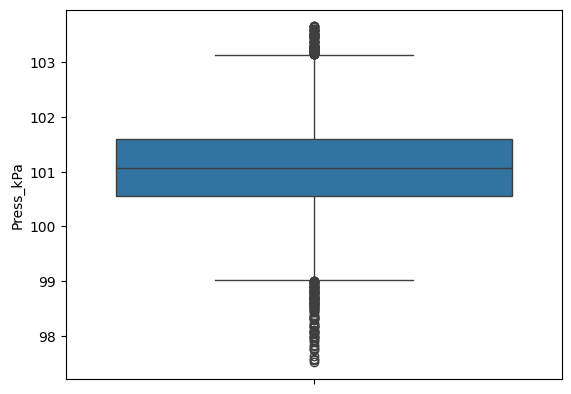

In [27]:
sns.boxplot(data=data['Press_kPa'])
plt.show()

In [28]:
print(data['Press_kPa'].skew())



-0.22992511978286803


In [29]:
data['Press_kPa'] = np.power(data['Press_kPa'], 3)

In [30]:
print(data['Press_kPa'].skew())

-0.1634547268654772


In [31]:
from scipy.stats import boxcox
data['Press_kPa'], lam = boxcox(data['Press_kPa'] + 1)
print(data['Press_kPa'].skew())

0.013778837417598784


In [32]:
import numpy as np

col = 'Press_kPa'   # column name

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Median replacement (better than mean for skewed data)
median_val = data[col].median()

data[col] = np.where(data[col] < lower_bound, median_val,
          np.where(data[col] > upper_bound, median_val, data[col]))

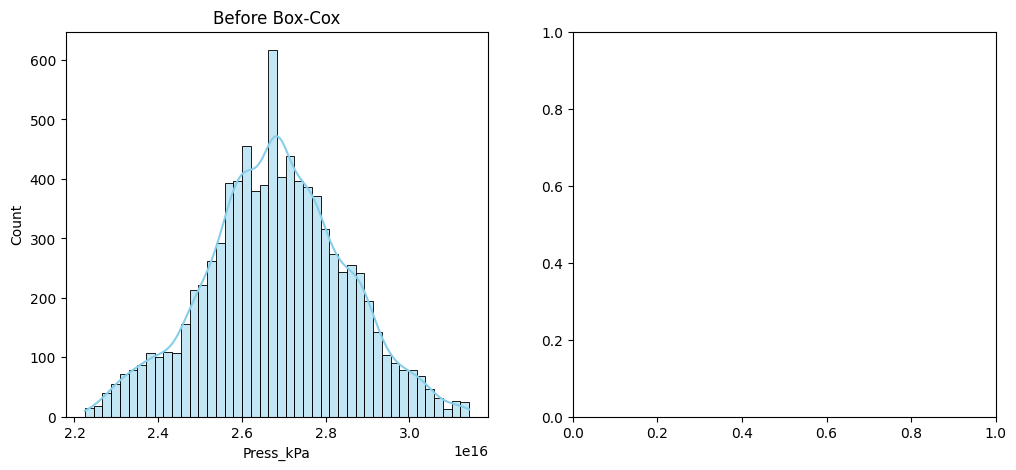

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Before transformation
sns.histplot(data['Press_kPa'], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Before Box-Cox")


plt.show()


In [34]:
"""from scipy.stats import boxcox
data['Press_kPa'], lam = boxcox(data['Press_kPa'] + 1)
print(data['Press_kPa'].skew())"""

"from scipy.stats import boxcox\ndata['Press_kPa'], lam = boxcox(data['Press_kPa'] + 1)  \nprint(data['Press_kPa'].skew())"

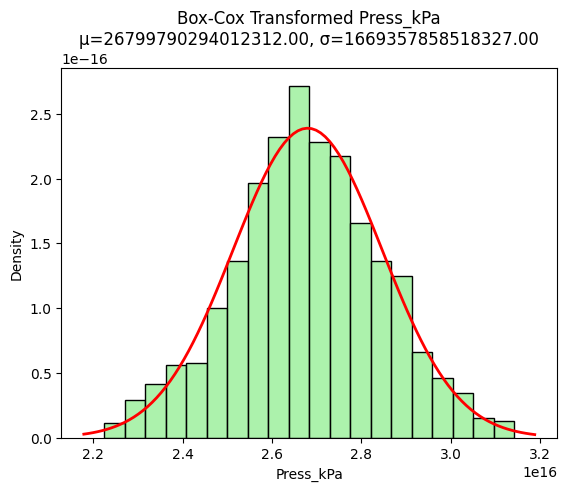

In [35]:
import numpy as np
from scipy.stats import norm

# Fit normal distribution to transformed data
mu, std = norm.fit(data['Press_kPa'])

# Plot histogram
sns.histplot(data['Press_kPa'], kde=False, stat="density", bins=20, color="lightgreen")

# Plot bell curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2)

plt.title(f"Box-Cox Transformed Press_kPa\nμ={mu:.2f}, σ={std:.2f}")
plt.show()


In [36]:
print(data['Press_kPa'].skew())

-0.024500903300573085


In [37]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
data['Temp_C_yeojohnson'] = pt.fit_transform(data[['Temp_C']])


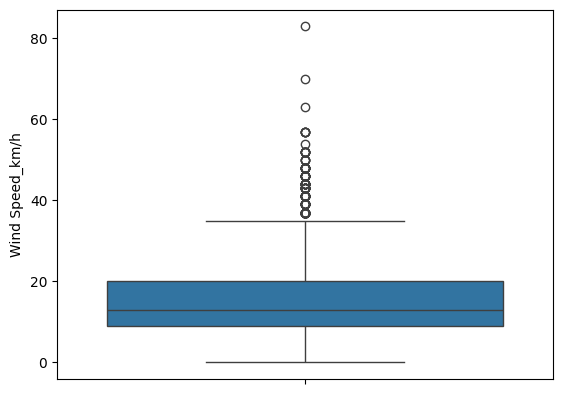

In [38]:
sns.boxplot(data=data['Wind Speed_km/h'])
plt.show()

In [39]:
z_scores = np.abs(stats.zscore(data['Wind Speed_km/h']))
data_clean = data[(z_scores < 3)]
data_clean

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Weather_Category,Temp_C_yeojohnson
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,2.718184e+16,Fog,Foggy,-0.901480
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,2.718184e+16,Fog,Foggy,-0.901480
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,2.722708e+16,"Freezing Drizzle,Fog",Rainy,-0.901480
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,2.724973e+16,"Freezing Drizzle,Fog",Rainy,-0.875349
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,2.715925e+16,Fog,Foggy,-0.875349
...,...,...,...,...,...,...,...,...,...,...
8779,12/31/2012 19:00,0.1,-2.7,81,30,9.7,2.477257e+16,Snow,Snowy,-0.736483
8780,12/31/2012 20:00,0.2,-2.4,83,24,9.7,2.456505e+16,Snow,Snowy,-0.727844
8781,12/31/2012 21:00,-0.5,-1.5,93,28,4.8,2.440015e+16,Snow,Snowy,-0.788433
8782,12/31/2012 22:00,-0.2,-1.8,89,28,9.7,2.431806e+16,Snow,Snowy,-0.762433
